# 01 — Data Load & Inspection
Loads the raw NESO half-hourly demand data (2021–2025), builds proper timestamps, and sanity-plots the National Demand series.

In [1]:

import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_path = "data/raw" if os.path.exists("data/raw") else "../data/raw"
files = sorted(glob.glob(f"{raw_path}/*.csv"))
print("Found files:")
for f in files:
    print(" ", f)

Found files:
  ../data/raw/demanddata_2021.csv
  ../data/raw/demanddata_2022.csv
  ../data/raw/demanddata_2023.csv
  ../data/raw/demanddata_2024.csv
  ../data/raw/demanddata_2025.csv


In [3]:
frames = []
for f in files:
    year_df = pd.read_csv(f)
    frames.append(year_df)

df = pd.concat(frames, ignore_index=True)
print("Combined shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Combined shape: (87648, 22)
Columns: ['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW', 'SCOTTISH_TRANSFER']


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER
0,01-JAN-2021,1,28354,28969,26130,1158,6527,0,13471,0,...,-1,0,215,203,999,0,0,0,0,NaN
1,01-JAN-2021,2,28501,29114,26281,1208,6527,0,13471,0,...,-1,0,359,203,999,0,0,0,0,NaN
2,01-JAN-2021,3,27759,28376,25557,1202,6527,0,13471,0,...,-1,0,362,202,999,0,0,0,0,NaN
3,01-JAN-2021,4,26912,27749,24792,1226,6527,0,13471,0,...,-1,0,361,203,1000,0,0,0,0,NaN
4,01-JAN-2021,5,26004,27178,23933,1193,6527,0,13471,0,...,-1,0,304,203,1000,0,0,0,0,NaN


In [5]:
# build a proper datetime from SETTLEMENT_DATE + SETTLEMENT_PERIOD ---
# SETTLEMENT_DATE looks like '01-JAN-2022'; SETTLEMENT_PERIOD is 1-48 (half-hours).
# Period 1 = 00:00-00:30, so minutes into the day = (period - 1) * 30.
df["date"] = pd.to_datetime(df["SETTLEMENT_DATE"], format="mixed", dayfirst=True)
df["datetime"] = df["date"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.sort_values("datetime").reset_index(drop=True)

print("Date range:", df["datetime"].min(), "->", df["datetime"].max())
print("Total half-hourly rows:", len(df))
df[["SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "datetime", "ND"]].head()


Date range: 2021-01-01 00:00:00 -> 2025-12-31 23:30:00
Total half-hourly rows: 87648


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,datetime,ND
0,01-JAN-2021,1,2021-01-01 00:00:00,28354
1,01-JAN-2021,2,2021-01-01 00:30:00,28501
2,01-JAN-2021,3,2021-01-01 01:00:00,27759
3,01-JAN-2021,4,2021-01-01 01:30:00,26912
4,01-JAN-2021,5,2021-01-01 02:00:00,26004


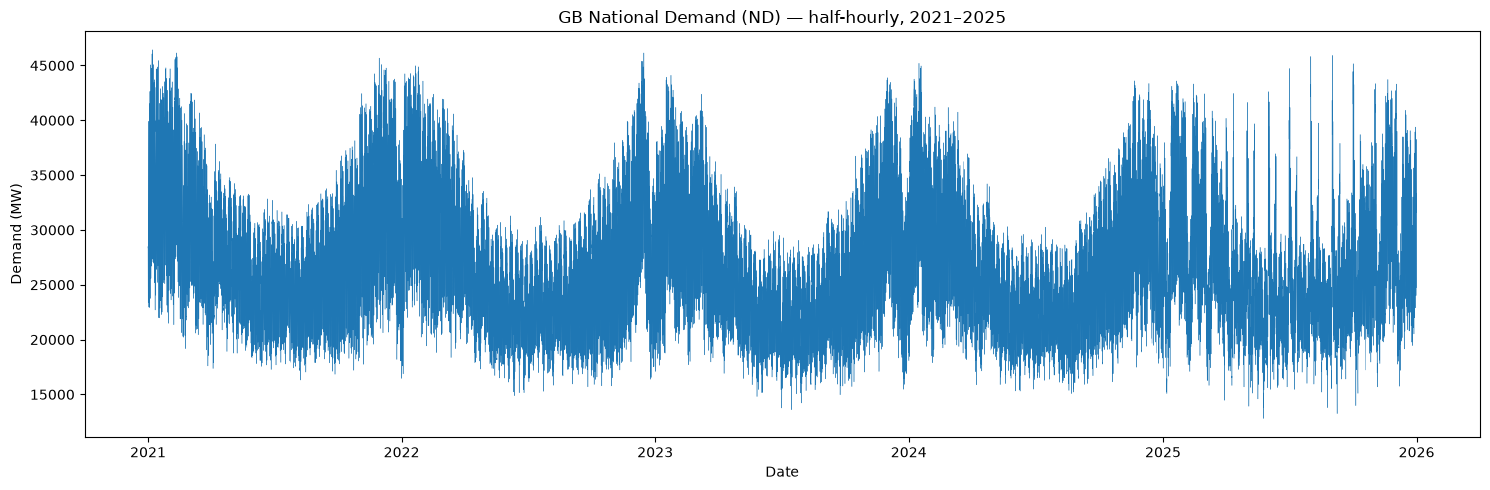

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(df["datetime"], df["ND"], linewidth=0.3)
plt.title("GB National Demand (ND) — half-hourly, 2021–2025")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.tight_layout()
plt.show()

In [7]:
print(df["ND"].describe())
print("\nMissing ND values:", df["ND"].isna().sum())

count    87648.000000
mean     26692.610487
std       6125.771290
min      12803.000000
25%      21900.000000
50%      25851.000000
75%      30551.000000
max      46433.000000
Name: ND, dtype: float64

Missing ND values: 0
